In [1]:
import pandas as pd
from sqlalchemy import create_engine
import geopandas as gpd
from dotenv import load_dotenv
load_dotenv()

import os

# Database connection details from zshrc environment variables
#  use .env file for local development


db_name = 'colorado_spills'
user = os.getenv('DB_USER')
password = os.getenv('DB_PASSWORD')
host = os.getenv('DB_HOST')
port = os.getenv('DB_PORT')


# Create an engine to connect to the PostgreSQL database
engine = create_engine(f'postgresql+psycopg2://{user}:{password}@{host}:{port}/{db_name}')

# Read in the spills_with_demographics_geog as spills
spills = pd.read_sql_table('spills_with_demographics_geog', engine)



/home/dadams/miniconda3/envs/spatial_env2/lib/python3.10/site-packages/pandas/io/sql.py:1725: SAWarning: Did not recognize type 'geometry' of column 'geometry'
  self.meta.reflect(bind=self.con, only=[table_name], views=True)


In [2]:
# use longitude and latitude to create a GeoDataFrame from spills data
spills['geometry'] = gpd.points_from_xy(spills['Longitude'], spills['Latitude'])

In [3]:
spills_gdf = gpd.GeoDataFrame(spills, crs='EPSG:4326') 


In [4]:

# Ensure date columns are in datetime format
spills_gdf['Date of Discovery'] = pd.to_datetime(spills_gdf['Date of Discovery'])
spills_gdf['Initial Report Date'] = pd.to_datetime(spills_gdf['Initial Report Date'])



In [5]:
# drop 2024 data for date of discovery and initial report date
spills_gdf = spills_gdf[spills_gdf['Date of Discovery'].dt.year < 2024]
spills_gdf = spills_gdf[spills_gdf['Initial Report Date'].dt.year < 2024]



In [6]:
# Separate Historical vs. Recent Spills
historical_spills = spills_gdf[spills_gdf['Spill Type'] == 'Historical']
recent_spills = spills_gdf[spills_gdf['Spill Type'] == 'Recent']


In [7]:
# Compare Reporting Delay
report_delay_summary = spills_gdf.groupby('Spill Type')['Report Delay (Days)'].describe()
print(report_delay_summary)

# Ensure the output directory exists
output_dir = 'analysis/output'
os.makedirs(output_dir, exist_ok=True)

# Save the report delay summary to a markdown file
with open(os.path.join(output_dir, 'report_delay_summary.md'), 'w') as f:
    f.write("# Report Delay Summary\n\n")
    f.write(report_delay_summary.to_markdown())


              count       mean         std  min  25%  50%  75%     max
Spill Type                                                            
Historical   5312.0  21.490023  205.615913  0.0  0.0  1.0  2.0  9261.0
Recent      10678.0   3.964506   46.997749  0.0  0.0  1.0  2.0  2232.0


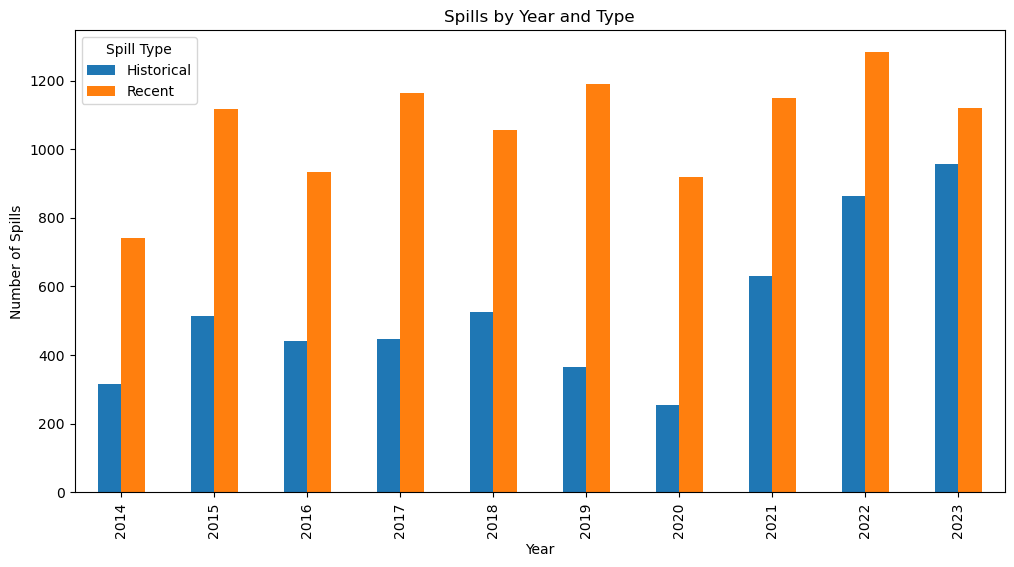

In [8]:
import matplotlib.pyplot as plt

# Compare Spill Trends Over Time
spills_by_year = spills_gdf.groupby(['Report Year', 'Spill Type']).size().unstack()
ax = spills_by_year.plot(kind='bar', figsize=(12,6), title='Spills by Year and Type')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Spills')
ax.legend(title='Spill Type')

# Ensure the output directory exists
output_dir = 'analysis/output'
os.makedirs(output_dir, exist_ok=True)

# Save the plot
plt.savefig(f'{output_dir}/spills_by_year_and_type.png')

# Display the plot
plt.show()

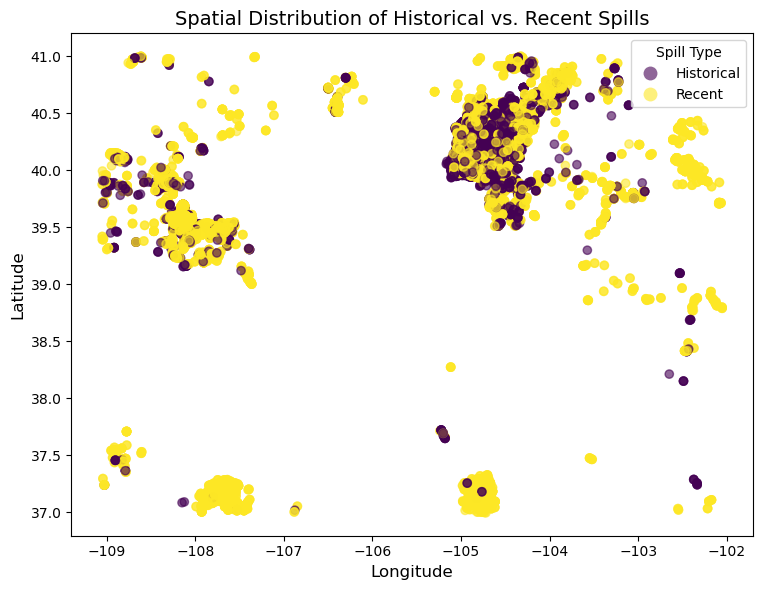

In [9]:
import matplotlib.pyplot as plt
import geopandas as gpd

# Ensure spills_gdf is already a GeoDataFrame with the necessary data
# spills_gdf = gpd.GeoDataFrame(...)

# Create a plot for the spatial distribution of spills
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the GeoDataFrame with optimizations
spills_gdf.plot(
    ax=ax,
    marker='o', 
    alpha=0.6,  # Adjust transparency for better visibility
    column='Spill Type', 
    legend=True, 
    legend_kwds={'title': "Spill Type"},  # Correctly specify the legend title
    cmap='viridis'  # Use a colormap for better visual distinction
)

# Set plot title and labels
ax.set_title('Spatial Distribution of Historical vs. Recent Spills', fontsize=14)
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)

# Improve layout
plt.tight_layout()

# Display the plot
plt.show()


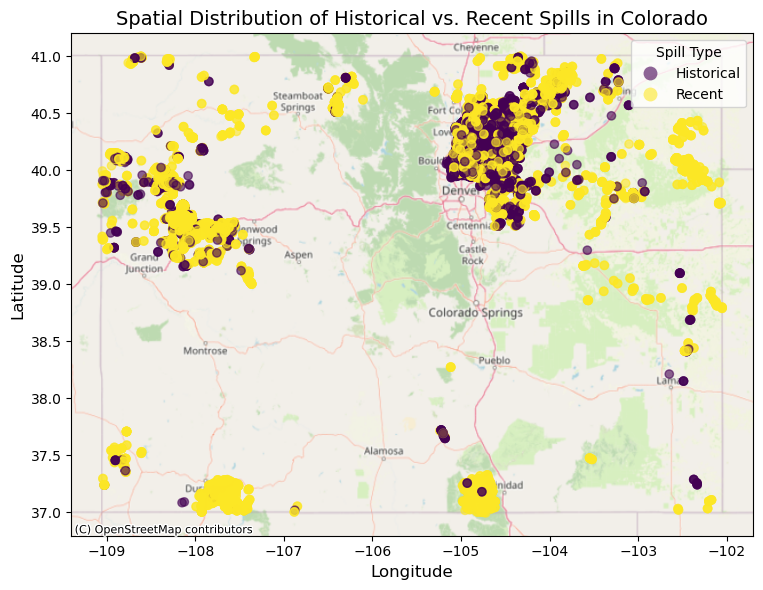

In [10]:
import matplotlib.pyplot as plt
import contextily as ctx
import numpy as np

# Use your ORIGINAL plot code exactly as it is, just adding the basemap at the end
# This ensures all your data points, colors and categories remain intact

# Starting with your original code:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the GeoDataFrame with optimizations - YOUR ORIGINAL PLOTTING CODE
spills_gdf.plot(
    ax=ax,
    marker='o',
    alpha=0.6,  # Adjust transparency for better visibility
    column='Spill Type',
    legend=True,
    legend_kwds={'title': "Spill Type"},  # Correctly specify the legend title
    cmap='viridis'  # Use a colormap for better visual distinction
)

# Set plot title and labels
ax.set_title('Spatial Distribution of Historical vs. Recent Spills in Colorado', fontsize=14)
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)

# Store the current axis limits to restore them after adding basemap
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# Before adding the basemap, convert the axes coordinates to Web Mercator
# This is a crucial step that lets us keep your original points exactly as they are
from pyproj import Transformer

# Create transformer from lat/lon to Web Mercator
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)

# Transform the limits
west, south = transformer.transform(xlim[0], ylim[0])
east, north = transformer.transform(xlim[1], ylim[1])

# Add the basemap - this will be UNDER your existing points
ctx.add_basemap(
    ax,
    crs=spills_gdf.crs,
    source=ctx.providers.OpenStreetMap.Mapnik,
    zoom="auto"
)

# Restore original axis limits
ax.set_xlim(xlim)
ax.set_ylim(ylim)

# Improve layout
plt.tight_layout()

# Save the plot to the analysis/output directory
output_dir = 'analysis/output'
os.makedirs(output_dir, exist_ok=True)
plt.savefig(f'{output_dir}/spatial_distribution_spills.png')

# Show the plot
plt.show()

In [11]:
# Add a column to indicate whether the spill occurred before or after 2021
spills_gdf['Period'] = spills_gdf['Report Year'].apply(lambda x: 'Before 2021' if x < 2021 else '2021 and After')

# Group by the new period column and calculate the mean response time
response_time_summary = spills_gdf.groupby('Period')['Report Delay (Days)'].describe()
print(response_time_summary)

# Ensure the output directory exists
output_dir = 'analysis/output'
os.makedirs(output_dir, exist_ok=True)

# Save the response time summary to a markdown file
with open(os.path.join(output_dir, 'response_time_summary.md'), 'w') as f:
    f.write("# Response Time Summary\n\n")
    f.write(response_time_summary.to_markdown())

                 count       mean         std  min  25%  50%  75%     max
Period                                                                   
2021 and After  6003.0   5.890055   65.333629  0.0  0.0  1.0  1.0  2501.0
Before 2021     9987.0  12.128767  149.585631  0.0  0.0  1.0  2.0  9261.0


T-Statistic: 3.6314
P-Value: 0.0003
The difference in response time is statistically significant.


<Axes: title={'center': 'Report Delay (Days)'}, xlabel='Period'>

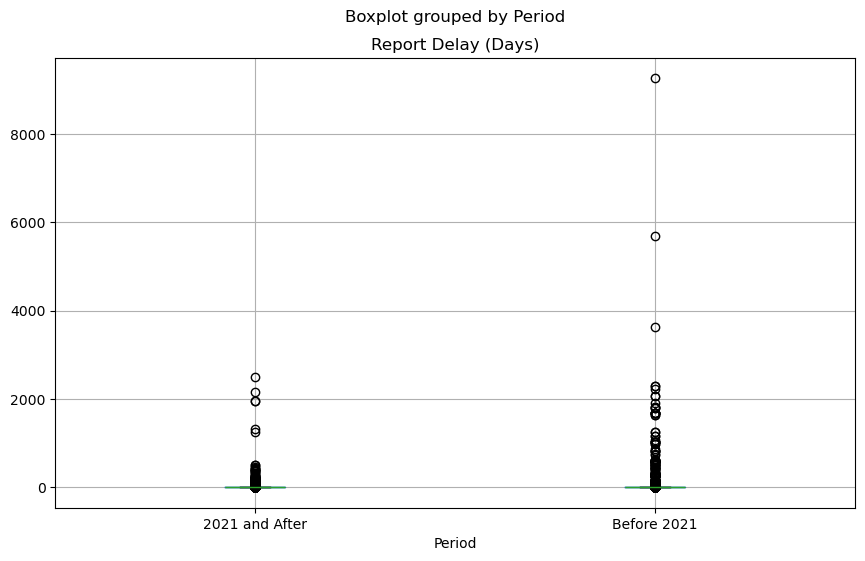

In [12]:
# t-test for the difference in response time before and after 2021
from scipy.stats import ttest_ind

before_2021 = spills_gdf[spills_gdf['Period'] == 'Before 2021']['Report Delay (Days)']
after_2021 = spills_gdf[spills_gdf['Period'] == '2021 and After']['Report Delay (Days)']

t_stat, p_value = ttest_ind(before_2021, after_2021, equal_var=False)
print(f'T-Statistic: {t_stat:.4f}')
print(f'P-Value: {p_value:.4f}')

# Check if the difference is statistically significant
if p_value < 0.05:
    print('The difference in response time is statistically significant.')
else:
    print('The difference in response time is not statistically significant.')
    
# Create a plot for the response time distribution before and after 2021
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the response time distribution for each period
spills_gdf.boxplot(column='Report Delay (Days)', by='Period', ax=ax)




In [13]:
%pip install tabulate

Note: you may need to restart the kernel to use updated packages.


In [14]:
import tabulate
from scipy.stats import ttest_ind

# Ensure the output directory exists
output_dir = 'analysis/output'
os.makedirs(output_dir, exist_ok=True)

# Add a column to indicate whether the spill occurred before or after 2021 for historical and recent spills
historical_spills['Period'] = historical_spills['Report Year'].apply(lambda x: 'Before 2021' if x < 2021 else '2021 and After')
recent_spills['Period'] = recent_spills['Report Year'].apply(lambda x: 'Before 2021' if x < 2021 else '2021 and After')

# Historical Spills Analysis
historical_report_delay_summary = historical_spills['Report Delay (Days)'].describe()
print("Historical Spills Report Delay Summary:")
print(historical_report_delay_summary)

# Recent Spills Analysis
recent_report_delay_summary = recent_spills['Report Delay (Days)'].describe()
print("\nRecent Spills Report Delay Summary:")
print(recent_report_delay_summary)

# Historical Spills Response Time Summary
historical_response_time_summary = historical_spills.groupby('Period')['Report Delay (Days)'].describe()
print("\nHistorical Spills Response Time Summary:")
print(historical_response_time_summary)

# Recent Spills Response Time Summary
recent_response_time_summary = recent_spills.groupby('Period')['Report Delay (Days)'].describe()
print("\nRecent Spills Response Time Summary:")
print(recent_response_time_summary)

# t-test for the difference in response time before and after 2021 for historical spills
historical_before_2021 = historical_spills[historical_spills['Period'] == 'Before 2021']['Report Delay (Days)']
historical_after_2021 = historical_spills[historical_spills['Period'] == '2021 and After']['Report Delay (Days)']

t_stat_historical, p_value_historical = ttest_ind(historical_before_2021, historical_after_2021, equal_var=False)
print(f'\nHistorical Spills T-Statistic: {t_stat_historical:.4f}')
print(f'Historical Spills P-Value: {p_value_historical:.4f}')

# Check if the difference is statistically significant for historical spills
if p_value_historical < 0.05:
    print('The difference in response time for historical spills is statistically significant.')
else:
    print('The difference in response time for historical spills is not statistically significant.')
    
# t-test for the difference in response time before and after 2021 for recent spills
recent_before_2021 = recent_spills[recent_spills['Period'] == 'Before 2021']['Report Delay (Days)']
recent_after_2021 = recent_spills[recent_spills['Period'] == '2021 and After']['Report Delay (Days)']

t_stat_recent, p_value_recent = ttest_ind(recent_before_2021, recent_after_2021, equal_var=False)
print(f'\nRecent Spills T-Statistic: {t_stat_recent:.4f}')
print(f'Recent Spills P-Value: {p_value_recent:.4f}')

# Check if the difference is statistically significant for recent spills
if p_value_recent < 0.05:
    print('The difference in response time for recent spills is statistically significant.')
else:
    print('The difference in response time for recent spills is not statistically significant.')

# Save the summaries and t-test results to a markdown file
with open(os.path.join(output_dir, 'analysis_results.md'), 'w') as f:
    f.write("# Analysis Results\n\n")
    
    f.write("## Historical Spills Report Delay Summary:\n")
    f.write(historical_report_delay_summary.to_markdown() + "\n\n")
    
    f.write("## Recent Spills Report Delay Summary:\n")
    f.write(recent_report_delay_summary.to_markdown() + "\n\n")
    
    f.write("## Historical Spills Response Time Summary:\n")
    f.write(historical_response_time_summary.to_markdown() + "\n\n")
    
    f.write("## Recent Spills Response Time Summary:\n")
    f.write(recent_response_time_summary.to_markdown() + "\n\n")
    
    f.write("## T-Test Results for Historical Spills\n")
    f.write(f"T-Statistic: {t_stat_historical:.4f}\n")
    f.write(f"P-Value: {p_value_historical:.4f}\n")
    if p_value_historical < 0.05:
        f.write('The difference in response time for historical spills is statistically significant.\n')
    else:
        f.write('The difference in response time for historical spills is not statistically significant.\n')
    
    f.write("\n## T-Test Results for Recent Spills\n")
    f.write(f"T-Statistic: {t_stat_recent:.4f}\n")
    f.write(f"P-Value: {p_value_recent:.4f}\n")
    if p_value_recent < 0.05:
        f.write('The difference in response time for recent spills is statistically significant.\n')
    else:
        f.write('The difference in response time for recent spills is not statistically significant.\n')

Historical Spills Report Delay Summary:
count    5312.000000
mean       21.490023
std       205.615913
min         0.000000
25%         0.000000
50%         1.000000
75%         2.000000
max      9261.000000
Name: Report Delay (Days), dtype: float64

Recent Spills Report Delay Summary:
count    10678.000000
mean         3.964506
std         46.997749
min          0.000000
25%          0.000000
50%          1.000000
75%          2.000000
max       2232.000000
Name: Report Delay (Days), dtype: float64

Historical Spills Response Time Summary:
                 count       mean         std  min  25%  50%  75%     max
Period                                                                   
2021 and After  2451.0  10.181559   96.011488  0.0  0.0  0.0  1.0  2501.0
Before 2021     2861.0  31.177910  265.348026  0.0  0.0  1.0  2.0  9261.0

Recent Spills Response Time Summary:
                 count      mean        std  min  25%  50%  75%     max
Period                                         

/home/dadams/miniconda3/envs/spatial_env2/lib/python3.10/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/home/dadams/miniconda3/envs/spatial_env2/lib/python3.10/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


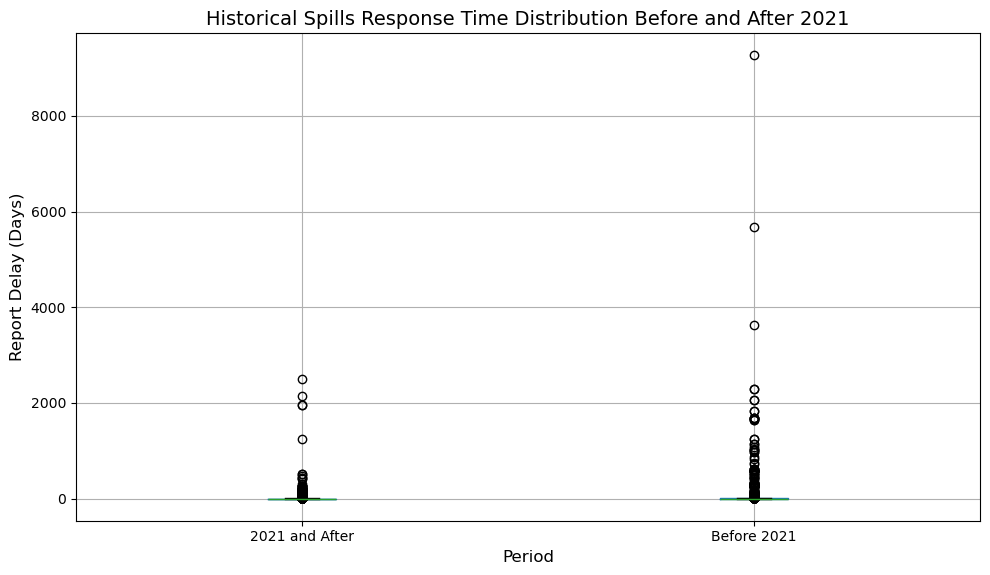

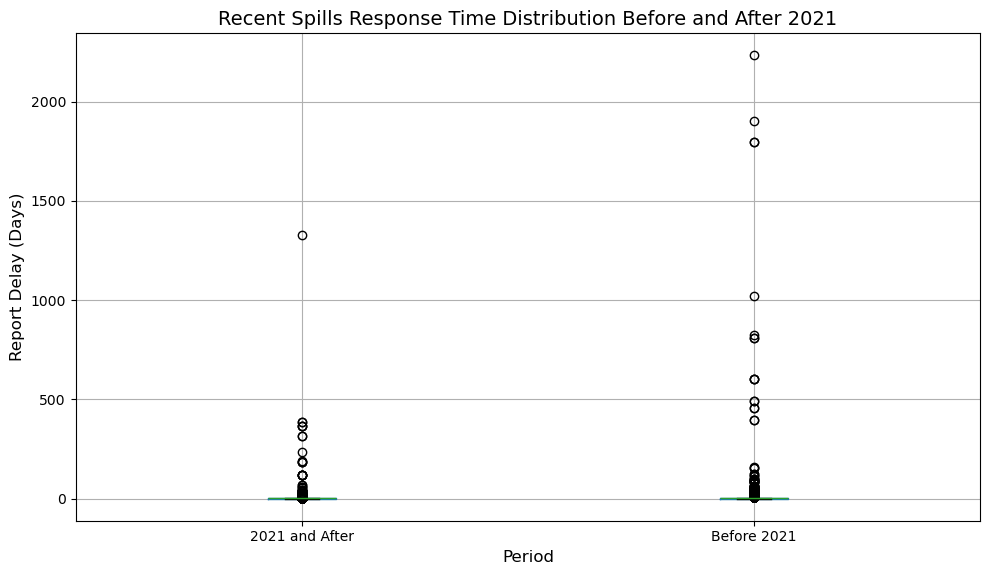

In [15]:
import os

# Ensure the output directory exists
output_dir = 'analysis/output'
os.makedirs(output_dir, exist_ok=True)

# Save the t-test results to a markdown file
with open(os.path.join(output_dir, 't_test_results.md'), 'w') as f:
    f.write(f"## T-Test Results for Historical Spills\n")
    f.write(f"T-Statistic: {t_stat_historical:.4f}\n")
    f.write(f"P-Value: {p_value_historical:.4f}\n")
    if p_value_historical < 0.05:
        f.write('The difference in response time for historical spills is statistically significant.\n')
    else:
        f.write('The difference in response time for historical spills is not statistically significant.\n')
    
    f.write(f"\n## T-Test Results for Recent Spills\n")
    f.write(f"T-Statistic: {t_stat_recent:.4f}\n")
    f.write(f"P-Value: {p_value_recent:.4f}\n")
    if p_value_recent < 0.05:
        f.write('The difference in response time for recent spills is statistically significant.\n')
    else:
        f.write('The difference in response time for recent spills is not statistically significant.\n')

# Create and save the plots
fig, ax = plt.subplots(figsize=(10, 6))
historical_spills.boxplot(column='Report Delay (Days)', by='Period', ax=ax)
ax.set_title('Historical Spills Response Time Distribution Before and After 2021', fontsize=14)
ax.set_xlabel('Period', fontsize=12)
ax.set_ylabel('Report Delay (Days)', fontsize=12)
plt.suptitle('')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'historical_spills_response_time_distribution.png'))

fig, ax = plt.subplots(figsize=(10, 6))
recent_spills.boxplot(column='Report Delay (Days)', by='Period', ax=ax)
ax.set_title('Recent Spills Response Time Distribution Before and After 2021', fontsize=14)
ax.set_xlabel('Period', fontsize=12)
ax.set_ylabel('Report Delay (Days)', fontsize=12)
plt.suptitle('')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'recent_spills_response_time_distribution.png'))

    


Historical Spills T-Statistic: 3.9419
Historical Spills P-Value: 0.0001
The difference in response time for historical spills is statistically significant.

Recent Spills T-Statistic: 1.9390
Recent Spills P-Value: 0.0525
The difference in response time for recent spills is not statistically significant.


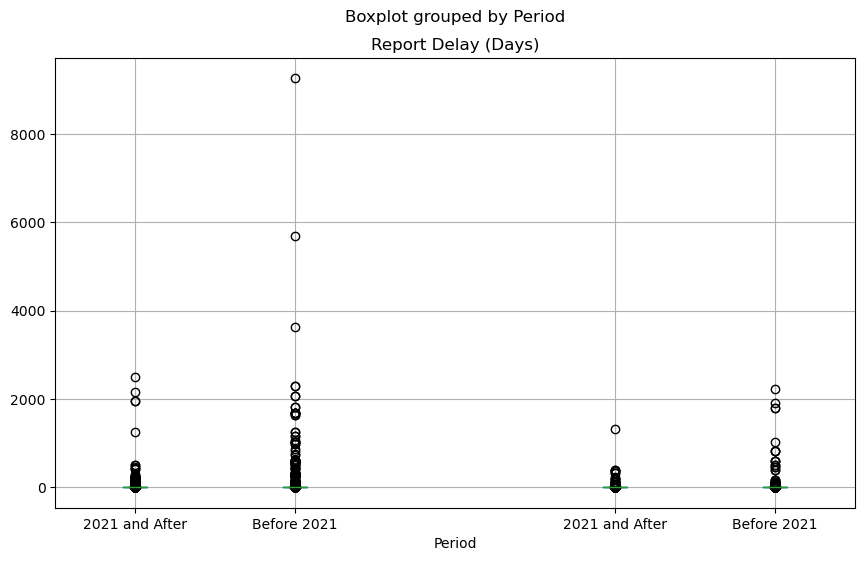

In [16]:
# t-test for the difference in response time before and after 2021 for historical spills
historical_before_2021 = historical_spills[historical_spills['Period'] == 'Before 2021']['Report Delay (Days)']
historical_after_2021 = historical_spills[historical_spills['Period'] == '2021 and After']['Report Delay (Days)']

t_stat, p_value = ttest_ind(historical_before_2021, historical_after_2021, equal_var=False)
print(f'\nHistorical Spills T-Statistic: {t_stat:.4f}')
print(f'Historical Spills P-Value: {p_value:.4f}')

# Check if the difference is statistically significant for historical spills
if p_value < 0.05:
    print('The difference in response time for historical spills is statistically significant.')
else:
    print('The difference in response time for historical spills is not statistically significant.')
    
# t-test for the difference in response time before and after 2021 for recent spills
recent_before_2021 = recent_spills[recent_spills['Period'] == 'Before 2021']['Report Delay (Days)']
recent_after_2021 = recent_spills[recent_spills['Period'] == '2021 and After']['Report Delay (Days)']

t_stat, p_value = ttest_ind(recent_before_2021, recent_after_2021, equal_var=False)
print(f'\nRecent Spills T-Statistic: {t_stat:.4f}')
print(f'Recent Spills P-Value: {p_value:.4f}')

# Check if the difference is statistically significant for recent spills
if p_value < 0.05:
    print('The difference in response time for recent spills is statistically significant.')
else:
    print('The difference in response time for recent spills is not statistically significant.')
    
# Create a plot for the response time distribution before and after 2021 for historical and recent spills
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the response time distribution for historical spills
historical_spills.boxplot(column='Report Delay (Days)', by='Period', ax=ax, positions=[1, 2])

# Plot the response time distribution for recent spills
recent_spills.boxplot(column='Report Delay (Days)', by='Period', ax=ax, positions=[4, 5])

# Save the plot to the /output directory
plt.savefig('analysis/output/response_time_distribution.png')
